In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import regularizers
from tensorflow.keras.utils import plot_model


In [ ]:
from pathlib import Path

cache_dir = Path(Path.home())
print(cache_dir)

/root


In [ ]:
import os
from zipfile import ZipFile
from shutil import copy
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pwd

/content


In [ ]:
# https://drive.google.com/file/d/1_AiafclQTYEBEbUJMZ1RSrZkfc8pb0bb/view?usp=sharing

# %cd ~/
!gdown --id 1Kc9yASltjq8-uas9vzU7i_JcqVQFckBh

!unzip -oq fer2013plus.zip -d $cache_dir
# !unzip -oq FER2013PLUSTest.zip -d $cache_dir

# !unzip -oq eval.zip -d $cache_dir

/usr/local/lib/python3.9/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Kc9yASltjq8-uas9vzU7i_JcqVQFckBh
To: /content/fer2013plus.zip
100% 138M/138M [00:01<00:00, 135MB/s]


In [ ]:
datagen=ImageDataGenerator(rescale=1.0/255,
                           validation_split=0.10,
                           fill_mode='nearest',
                           horizontal_flip=True,
                           rotation_range=10,
                           width_shift_range=0.05,
                           height_shift_range=0.05,
                           shear_range=30,
                           zoom_range=0.05
                           )
directory = '/root/fer2013plus/train'

# Provide the same seed and keyword arguments to the fit and flow methods
seed = 12321

train_generator = datagen.flow_from_directory(directory, color_mode = 'grayscale', subset= "training",
                                              target_size=(96,96), shuffle=True,# label_mode = 'int',
                                              batch_size=32)

valid_generator = datagen.flow_from_directory(directory, subset= "validation",  # label_mode = 'int',
                                              color_mode = 'grayscale', target_size=(96,96),
                                              shuffle=True, batch_size=32)

# Found 31289 images belonging to 6 classes.
# Found 5518 images belonging to 6 classes.

Found 25551 images belonging to 8 classes.
Found 2835 images belonging to 8 classes.


## model arch

In [ ]:
model = tf.keras.models.Sequential(
                                     [tf.keras.layers.Conv2D(32, (3,3), input_shape = (96,96,1), padding='same'),
                                    #  tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(32, (3,3), padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.AvgPool2D(2,2),
                                    #  tf.keras.layers.MaxPool2D(2, 2),

                                    #
                                     tf.keras.layers.Conv2D(32, (1,1), padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(64, (3,3), padding='same'),
                                      tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(64, (3,3),  padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.MaxPool2D(3, 2, padding='same'),

                                    #
                                     tf.keras.layers.Conv2D(64, (1,1), padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(128, (5,1), padding='same'),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(128, (1,5), padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(128, (5,1), padding='same'),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(128, (1,5), padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.MaxPool2D(3, 2, padding='same'),
                                     tf.keras.layers.Dropout(0.3),
                                    #
                                     tf.keras.layers.Conv2D(92, (1,1), padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(128, (5,1), padding='same'),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Conv2D(128, (1,5), padding='same'),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.MaxPool2D(3, 2, padding='same'),
                                     tf.keras.layers.Dropout(0.3),
                                     tf.keras.layers.Flatten(),
                                    #
                                     tf.keras.layers.Dense(256),
                                     tf.keras.layers.BatchNormalization(),
                                     tf.keras.layers.Activation('relu'),
                                     tf.keras.layers.Dropout(0.4),
                                     tf.keras.layers.Dense(8, activation = 'softmax')
                                     ]
                                   )


In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile( loss =  "categorical_crossentropy",
               optimizer = Adam(learning_rate=0.0001),
               metrics = ['accuracy',tf.keras.metrics.Precision()]
            )

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("FER_model.h5", save_best_only=True,
                                                   monitor = 'val_loss', mode = 'min',verbose=1
                                                   )


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0000001,verbose=1)

In [ ]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_35 (Conv2D)          (None, 96, 96, 32)        320       
                                                                 
 activation_37 (Activation)  (None, 96, 96, 32)        0         
                                                                 
 conv2d_36 (Conv2D)          (None, 96, 96, 32)        9248      
                                                                 
 batch_normalization_24 (Bat  (None, 96, 96, 32)       128       
 chNormalization)                                                
                                                                 
 activation_38 (Activation)  (None, 96, 96, 32)        0         
                                                                 
 average_pooling2d_3 (Averag  (None, 48, 48, 32)       0         
 ePooling2D)                                          

In [ ]:
# Total params: 14,100,284
# Trainable params: 14,098,676
# Non-trainable params: 1,608

In [ ]:

history = model.fit(
    train_generator, epochs=50,
    validation_data=valid_generator,
    callbacks = [
                #  PlotLossesKerasTF(),
                 checkpoint_cb,
                 reduce_lr]
)

Epoch 1/50
799/799 [==============================] - ETA: 0s - loss: 1.8561 - accuracy: 0.3286 - precision_3: 0.3967
Epoch 1: val_loss improved from inf to 1.52295, saving model to FER_model.h5
799/799 [==============================] - 71s 78ms/step - loss: 1.8561 - accuracy: 0.3286 - precision_3: 0.3967 - val_loss: 1.5229 - val_accuracy: 0.4317 - val_precision_3: 0.5298 - lr: 1.0000e-04
Epoch 2/50
799/799 [==============================] - ETA: 0s - loss: 1.5464 - accuracy: 0.4445 - precision_3: 0.5381
Epoch 2: val_loss improved from 1.52295 to 1.42587, saving model to FER_model.h5
799/799 [==============================] - 56s 70ms/step - loss: 1.5464 - accuracy: 0.4445 - precision_3: 0.5381 - val_loss: 1.4259 - val_accuracy: 0.5005 - val_precision_3: 0.5722 - lr: 1.0000e-04
Epoch 3/50
799/799 [==============================] - ETA: 0s - loss: 1.3439 - accuracy: 0.5294 - precision_3: 0.6303
Epoch 3: val_loss improved from 1.42587 to 1.32381, saving model to FER_model.h5
799/799 [==

In [ ]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'precision_3', 'val_loss', 'val_accuracy', 'val_precision_3', 'lr'])

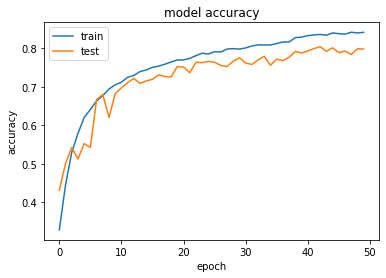

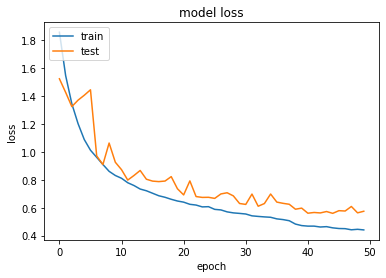

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

<ipython-input-44-a8087a20b118>:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, acc, 'r', "Training Accuracy", color='green',)
<ipython-input-44-a8087a20b118>:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_acc, 'b', "Validation Accuracy", color='red')
<ipython-input-44-a8087a20b118>:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'r', "Training Loss", color='green')
<ipython-input-44-a8087a20b118>:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argume

Text(0.5, 1.0, 'Training and validation loss')

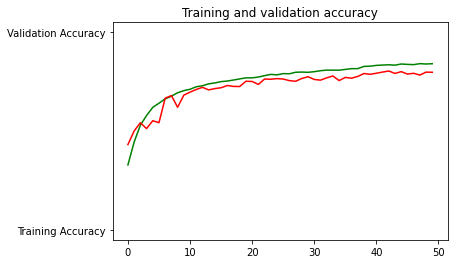

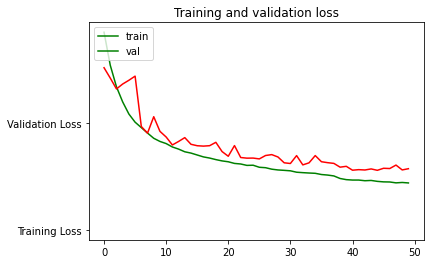

In [ ]:
# PLOT LOSS AND ACCURACY
%matplotlib inline

import matplotlib.image  as mpimg
import matplotlib.pyplot as plt

#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', "Training Accuracy", color='green',)
plt.plot(epochs, val_acc, 'b', "Validation Accuracy", color='red')
plt.title('Training and validation accuracy')
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r', "Training Loss", color='green')
plt.plot(epochs, val_loss, 'b', "Validation Loss", color='red')

plt.legend(['train', 'val'], loc='upper left')

plt.title('Training and validation loss')

# Desired output. Charts with training and validation metrics. No crash :)

In [ ]:
model_path = '/content/drive/MyDrive/ferplus_50_epoc_Nov25.h5'
model.save(model_path)

In [ ]:
# model = tf.keras.models.load_model("/content/drive/MyDrive/ferplus_100_epoc_feb20.h5")

In [ ]:
testgen = ImageDataGenerator( rescale = 1/255, horizontal_flip=True, fill_mode="nearest" )
directory = '/root/fer2013plus/test'

# Provide the same seed and keyword arguments to the fit and flow methods
seed = 12321

test_generator = testgen.flow_from_directory(directory, color_mode = 'grayscale',
                                              target_size=(96,96), shuffle=False,# label_mode = 'int',
                                              seed=seed, batch_size=8)
test_generator.reset()

Found 7099 images belonging to 8 classes.


In [ ]:
train_generator.labels

array([0, 0, 0, ..., 7, 7, 7], dtype=int32)

In [ ]:
classes = test_generator.class_indices
classes = dict((v,k) for k,v in classes.items())
classes.values()

dict_values(['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise'])

In [ ]:
y_true = test_generator.labels

In [ ]:
# predict test data
y_pred=model.predict(test_generator, verbose=1)

888/888 [==============================] - 8s 9ms/step


In [ ]:
# dominant value for each image
predicted_class_indices=np.argmax(y_pred,axis=1)
predicted_class_indices

array([0, 0, 0, ..., 7, 7, 7])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
target_names = ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
print(classification_report(y_true, predicted_class_indices, target_names=target_names))


              precision    recall  f1-score   support

       anger       0.75      0.77      0.76       644
    contempt       0.75      0.06      0.11        51
     disgust       0.74      0.25      0.37        57
        fear       0.64      0.42      0.51       167
   happiness       0.90      0.92      0.91      1827
     neutral       0.79      0.90      0.84      2597
     sadness       0.80      0.47      0.59       856
    surprise       0.80      0.88      0.84       900

    accuracy                           0.82      7099
   macro avg       0.77      0.58      0.62      7099
weighted avg       0.81      0.82      0.80      7099



<Axes: >

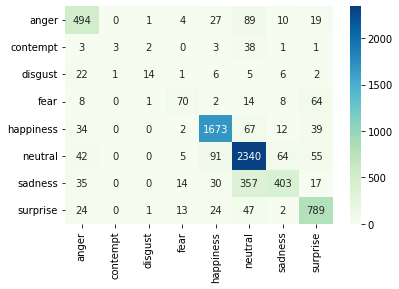

In [ ]:
labels = ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
sns.heatmap(confusion_matrix(y_true, predicted_class_indices), annot = True,fmt="d",
            cmap="GnBu", xticklabels=labels, yticklabels=labels)

<Axes: >

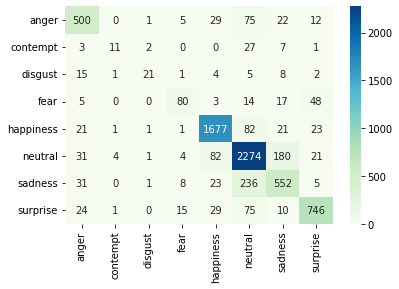

In [ ]:
labels = ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
sns.heatmap(confusion_matrix(y_true, predicted_class_indices), annot = True,fmt="d",
            cmap="GnBu", xticklabels=labels, yticklabels=labels)

<Axes: >

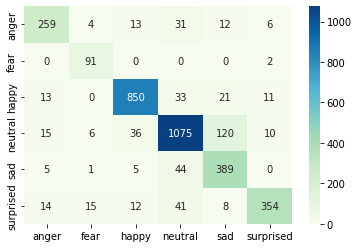

In [ ]:
labels = ['anger', 'fear', 'happy', 'neutral', 'sad', 'surprised']
sns.heatmap(confusion_matrix(y_true, predicted_class_indices), annot = True,fmt="d",
            cmap="GnBu", xticklabels=labels, yticklabels=labels)

In [ ]:
# create table for filename and it's respective predicted class/label
import pandas as pd
filenames = test_generator.filenames
results=pd.DataFrame({"Filename":filenames,
                      "Actual": actual_labels,
                      "Predictions":predictions,
                      })
results.to_csv('/content/drive/MyDrive/ferplus_100_epoc_feb20.csv')


In [ ]:
# check test results... [correct_prediction, Total_images_in_each_class]

label_count = {'angry': [0,0], 'fearful': [0,0], 'happy': [0,0], 'neutral': [0,0], 'sad': [0,0], 'surprised': [0,0]}

for index, row in results.iterrows():
  label=row['Filename'].split("/")[0]
  label_count[label][1] += 1
  if label == row['Predictions']:
    label_count[label][0] += 1
print(label_count)

{'angry': [216, 325], 'fearful': [85, 93], 'happy': [832, 928], 'neutral': [1146, 1262], 'sad': [246, 444], 'surprised': [355, 444]}


In [ ]:
predicted_class_indices[0]

0